In [6]:
# Resource Type Demand Analysis

resource_type_demand = (
    df.groupby("Type", as_index=False)["Loans"]
      .sum()
      .sort_values("Loans", ascending=False)
)

print("Demand by Resource Type:")
display(resource_type_demand)

Demand by Resource Type:


,Type,Loans
48,emagazines and enewspapers,955262
9,Children's fiction,809814
1,Adult fiction,394122
3,Adult non fiction,250832
46,ebooks,195409
45,eaudio,131022
37,SLS Non Fiction,110754
11,Children's non fiction,97567
41,Teenage fiction,64257
23,Large print adult fiction,37802


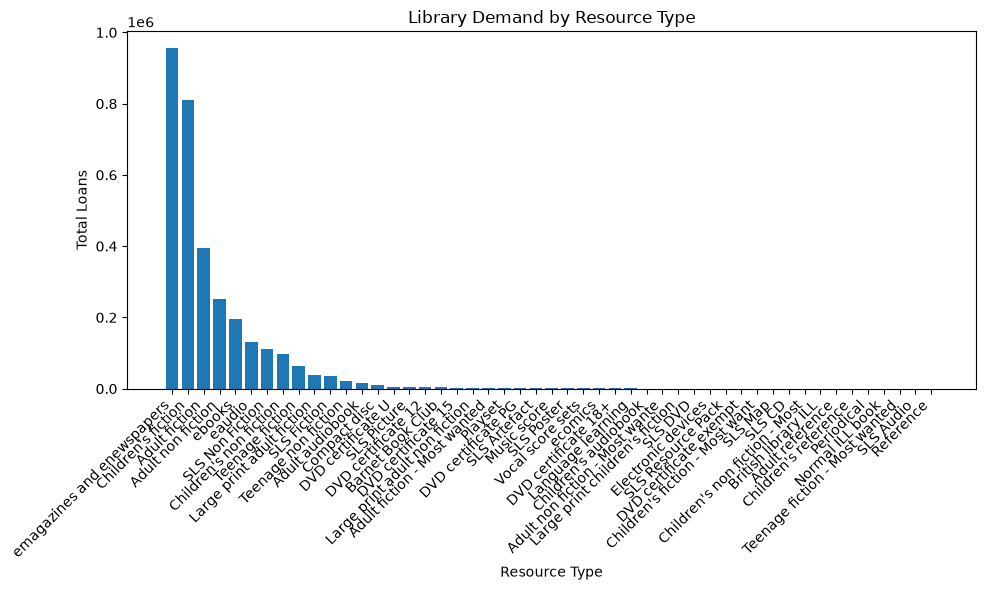

In [7]:
# Resource Type Demand Visualization

plt.figure(figsize=(10, 6))

plt.bar(
    resource_type_demand["Type"],
    resource_type_demand["Loans"]
)

plt.xlabel("Resource Type")
plt.ylabel("Total Loans")
plt.title("Library Demand by Resource Type")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.savefig("resource_type_demand.png", dpi=300)

plt.show()

In [8]:
# Monthly Library Demand

monthly_demand = (
    df.groupby("Month", as_index=False)["Loans"]
      .sum()
      .sort_values("Month")
)

monthly_demand.columns = ["Month", "Total_Loans"]

print("Monthly Demand:")
display(monthly_demand.head(10))

Monthly Demand:


,Month,Total_Loans
0,2019-04-01,95730
1,2019-05-01,90772
2,2019-06-01,84325
3,2019-07-01,93329
4,2019-08-01,115605
5,2019-09-01,94024
6,2019-10-01,110064
7,2019-11-01,106752
8,2019-12-01,100374
9,2020-01-01,101442


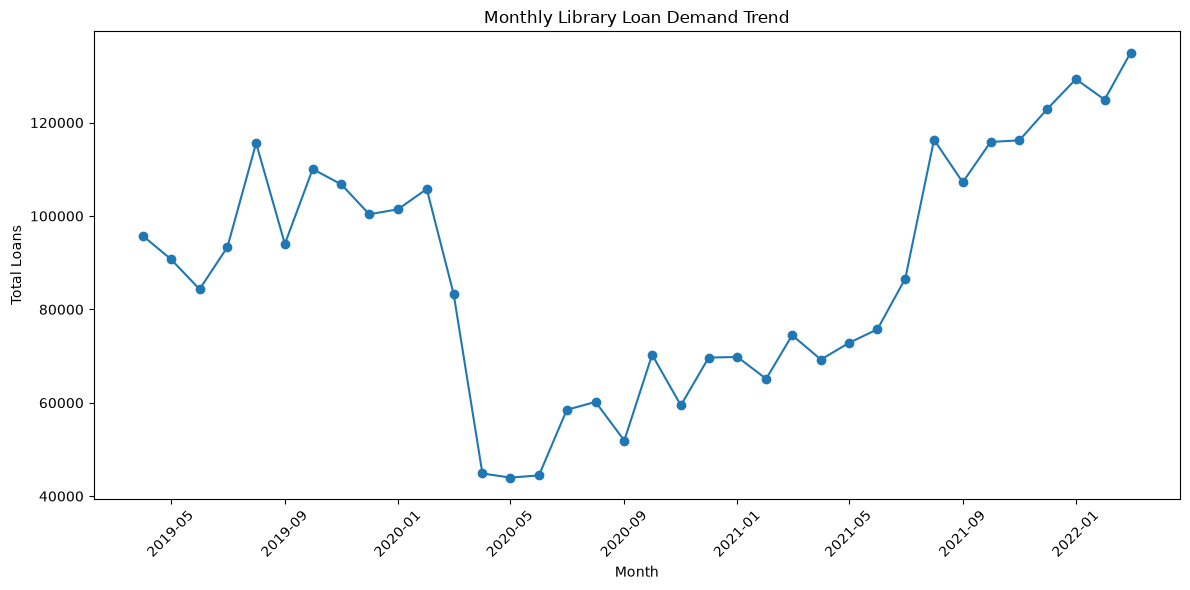

In [9]:
# Monthly Demand Trend Visualization

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_demand["Month"],
    monthly_demand["Total_Loans"],
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Total Loans")
plt.title("Monthly Library Loan Demand Trend")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("monthly_demand_trend.png", dpi=300)

plt.show()

In [10]:
# Save Monthly Demand Data

monthly_demand.to_csv(
    "monthly_library_demand.csv",
    index=False
)

print("monthly_library_demand.csv saved successfully!")

monthly_library_demand.csv saved successfully!


In [11]:
# Save Resource Type Demand Data

resource_type_demand.to_csv(
    "resource_type_demand.csv",
    index=False
)

print("resource_type_demand.csv saved successfully!")

resource_type_demand.csv saved successfully!


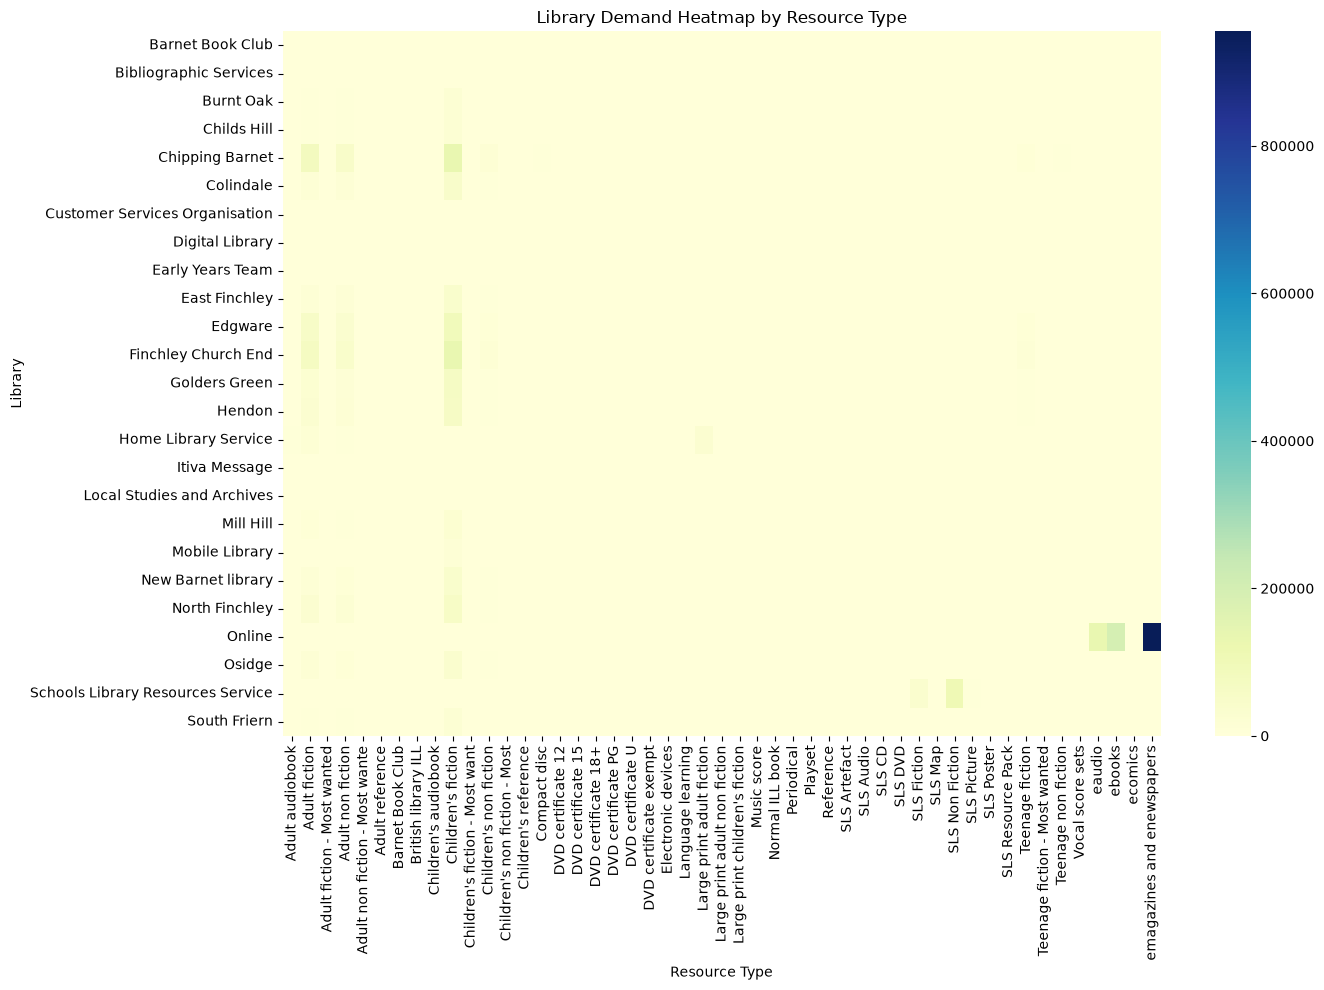

In [12]:
# Library and Resource Type Demand Heatmap

heatmap_data = pd.pivot_table(
    df,
    values="Loans",
    index="Library name",
    columns="Type",
    aggfunc="sum",
    fill_value=0
)

plt.figure(figsize=(14, 10))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu"
)

plt.title("Library Demand Heatmap by Resource Type")
plt.xlabel("Resource Type")
plt.ylabel("Library")

plt.tight_layout()

plt.savefig("demand_heatmap.png", dpi=300)

plt.show()

In [13]:
# Prepare Data for Demand Forecasting

forecast_data = monthly_demand.copy()

# Create a numerical time index
forecast_data["Time_Index"] = np.arange(len(forecast_data))

X = forecast_data[["Time_Index"]]
y = forecast_data["Total_Loans"]

print("Forecasting data prepared successfully!")
display(forecast_data.head())

Forecasting data prepared successfully!


,Month,Total_Loans,Time_Index
0,2019-04-01,95730,0
1,2019-05-01,90772,1
2,2019-06-01,84325,2
3,2019-07-01,93329,3
4,2019-08-01,115605,4


In [14]:
# Train Linear Regression Model

model = LinearRegression()

model.fit(X, y)

print("Linear Regression model trained successfully!")
print("Model coefficient:", model.coef_[0])
print("Model intercept:", model.intercept_)

Linear Regression model trained successfully!
Model coefficient: 623.0577863577863
Model intercept: 77049.57207207207


In [15]:
# Forecast the Next 6 Months

forecast_periods = 6

last_month = forecast_data["Month"].max()

future_months = pd.date_range(
    start=last_month + pd.DateOffset(months=1),
    periods=forecast_periods,
    freq="MS"
)

future_time_index = np.arange(
    len(forecast_data),
    len(forecast_data) + forecast_periods
)

future_predictions = model.predict(
    future_time_index.reshape(-1, 1)
)

# Prevent negative predictions
future_predictions = np.maximum(future_predictions, 0)

forecast_df = pd.DataFrame({
    "Month": future_months,
    "Forecasted_Loans": np.round(future_predictions).astype(int)
})

print("Next 6 months forecast:")
display(forecast_df)

Next 6 months forecast:


c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


,Month,Forecasted_Loans
0,2022-04-01,99480
1,2022-05-01,100103
2,2022-06-01,100726
3,2022-07-01,101349
4,2022-08-01,101972
5,2022-09-01,102595


In [16]:
# Demand Level Classification

historical_average = forecast_data["Total_Loans"].mean()

high_threshold = historical_average * 1.20
low_threshold = historical_average * 0.80

def classify_demand(value):
    if value >= high_threshold:
        return "High Demand"
    elif value <= low_threshold:
        return "Low Demand"
    else:
        return "Medium Demand"

forecast_df["Demand_Level"] = forecast_df["Forecasted_Loans"].apply(
    classify_demand
)

print("Historical average monthly demand:", round(historical_average, 2))
print("High-demand threshold:", round(high_threshold, 2))
print("Low-demand threshold:", round(low_threshold, 2))

display(forecast_df)

Historical average monthly demand: 87953.08
High-demand threshold: 105543.7
Low-demand threshold: 70362.47


,Month,Forecasted_Loans,Demand_Level
0,2022-04-01,99480,Medium Demand
1,2022-05-01,100103,Medium Demand
2,2022-06-01,100726,Medium Demand
3,2022-07-01,101349,Medium Demand
4,2022-08-01,101972,Medium Demand
5,2022-09-01,102595,Medium Demand


In [17]:
# Save Forecast Results

forecast_df.to_csv(
    "library_demand_forecast.csv",
    index=False
)

print("library_demand_forecast.csv saved successfully!")

library_demand_forecast.csv saved successfully!


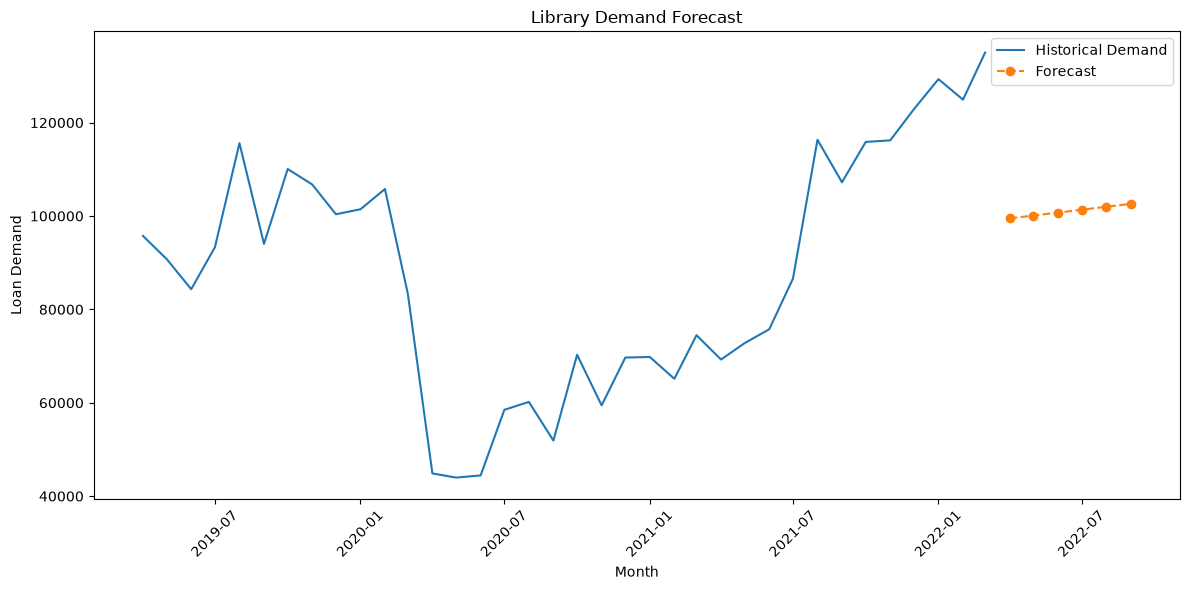

In [18]:
# Historical Demand vs Forecast

plt.figure(figsize=(12, 6))

plt.plot(
    forecast_data["Month"],
    forecast_data["Total_Loans"],
    label="Historical Demand"
)

plt.plot(
    forecast_df["Month"],
    forecast_df["Forecasted_Loans"],
    marker="o",
    linestyle="--",
    label="Forecast"
)

plt.xlabel("Month")
plt.ylabel("Loan Demand")
plt.title("Library Demand Forecast")

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("library_demand_forecast.png", dpi=300)

plt.show()

In [19]:
# Resource Optimization Recommendations

def generate_recommendation(demand_level):
    if demand_level == "High Demand":
        return "Increase book availability, staff support and borrowing capacity"
    elif demand_level == "Low Demand":
        return "Reduce excess stock and promote underused resources"
    else:
        return "Maintain normal inventory and staffing levels"

forecast_df["Resource_Recommendation"] = forecast_df["Demand_Level"].apply(
    generate_recommendation
)

resource_optimization = forecast_df[
    [
        "Month",
        "Forecasted_Loans",
        "Demand_Level",
        "Resource_Recommendation"
    ]
].copy()

display(resource_optimization)

,Month,Forecasted_Loans,Demand_Level,Resource_Recommendation
0,2022-04-01,99480,Medium Demand,Maintain normal inventory and staffing levels
1,2022-05-01,100103,Medium Demand,Maintain normal inventory and staffing levels
2,2022-06-01,100726,Medium Demand,Maintain normal inventory and staffing levels
3,2022-07-01,101349,Medium Demand,Maintain normal inventory and staffing levels
4,2022-08-01,101972,Medium Demand,Maintain normal inventory and staffing levels
5,2022-09-01,102595,Medium Demand,Maintain normal inventory and staffing levels


In [20]:
# Save Resource Optimization Results

resource_optimization.to_csv(
    "library_resource_optimization.csv",
    index=False
)

print("library_resource_optimization.csv saved successfully!")

library_resource_optimization.csv saved successfully!


In [21]:
# Final Project Summary

print("=" * 60)
print("SMART LIBRARY DEMAND FORECASTING & RESOURCE OPTIMIZATION")
print("=" * 60)

print("\nDataset rows after cleaning:", len(df))
print("Libraries analyzed:", df["Library name"].nunique())
print("Resource types analyzed:", df["Type"].nunique())
print("Historical months analyzed:", len(monthly_demand))

print(
    "\nHistorical average monthly loans:",
    round(historical_average, 2)
)

print("\nNext 6 Months Forecast:")
display(resource_optimization)

print("\nGenerated Project Files:")

files = [
    "top_10_libraries.png",
    "resource_type_demand.png",
    "monthly_demand_trend.png",
    "demand_heatmap.png",
    "library_demand_forecast.png",
    "monthly_library_demand.csv",
    "resource_type_demand.csv",
    "library_demand_forecast.csv",
    "library_resource_optimization.csv"
]

for file in files:
    print("✓", file)

print("\nPROJECT COMPLETED SUCCESSFULLY!")

SMART LIBRARY DEMAND FORECASTING & RESOURCE OPTIMIZATION

Dataset rows after cleaning: 8670
Libraries analyzed: 25
Resource types analyzed: 49
Historical months analyzed: 36

Historical average monthly loans: 87953.08

Next 6 Months Forecast:


,Month,Forecasted_Loans,Demand_Level,Resource_Recommendation
0,2022-04-01,99480,Medium Demand,Maintain normal inventory and staffing levels
1,2022-05-01,100103,Medium Demand,Maintain normal inventory and staffing levels
2,2022-06-01,100726,Medium Demand,Maintain normal inventory and staffing levels
3,2022-07-01,101349,Medium Demand,Maintain normal inventory and staffing levels
4,2022-08-01,101972,Medium Demand,Maintain normal inventory and staffing levels
5,2022-09-01,102595,Medium Demand,Maintain normal inventory and staffing levels



Generated Project Files:
✓ top_10_libraries.png
✓ resource_type_demand.png
✓ monthly_demand_trend.png
✓ demand_heatmap.png
✓ library_demand_forecast.png
✓ monthly_library_demand.csv
✓ resource_type_demand.csv
✓ library_demand_forecast.csv
✓ library_resource_optimization.csv

PROJECT COMPLETED SUCCESSFULLY!


In [ ]:
# Dataset Information

print("Number of rows:", len(df))
print("Number of columns:", len(df.columns))

print("\nColumns:")
print(df.columns.tolist())

print("\nDate range:")
print(df["Month"].min(), "to", df["Month"].max())

print("\nNumber of libraries:", df["Library name"].nunique())
print("Number of resource types:", df["Type"].nunique())

print("\nLoan statistics:")
display(df["Loans"].describe())

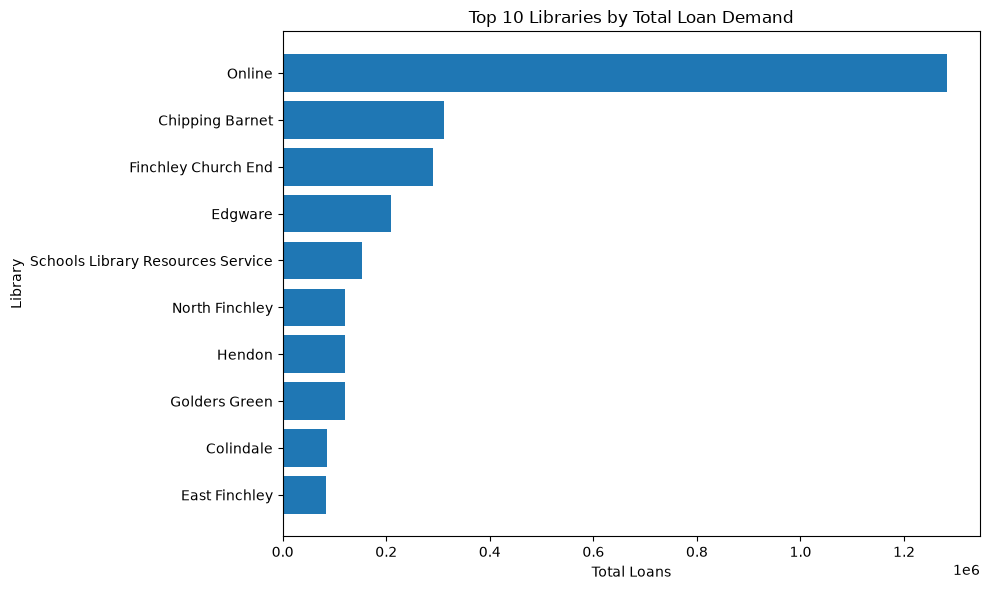

In [5]:
# Top 10 Libraries Visualization

top_10 = library_demand.head(10).sort_values("Loans")

plt.figure(figsize=(10, 6))

plt.barh(
    top_10["Library name"],
    top_10["Loans"]
)

plt.xlabel("Total Loans")
plt.ylabel("Library")
plt.title("Top 10 Libraries by Total Loan Demand")

plt.tight_layout()

plt.savefig("top_10_libraries.png", dpi=300)

plt.show()

In [4]:
# Total Loan Demand by Library

library_demand = (
    df.groupby("Library name", as_index=False)["Loans"]
      .sum()
      .sort_values("Loans", ascending=False)
)

print("Top 10 Libraries by Total Loan Demand:")
display(library_demand.head(10))

Top 10 Libraries by Total Loan Demand:


,Library name,Loans
21,Online,1282534
4,Chipping Barnet,312502
11,Finchley Church End,290630
10,Edgware,208354
23,Schools Library Resources Service,153913
20,North Finchley,120924
13,Hendon,120508
12,Golders Green,119545
5,Colindale,85730
9,East Finchley,83309


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Data Cleaning and Preprocessing

# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Convert Month column to datetime
df["Month"] = pd.to_datetime(df["Month"], errors="coerce")

# Convert Loans column to numeric
df["Loans"] = pd.to_numeric(df["Loans"], errors="coerce")

# Check missing values
print("Missing values before cleaning:")
print(df.isnull().sum())

# Remove rows with missing important values
df = df.dropna(subset=["Library name", "Month", "Type", "Loans"])

# Remove negative loan values
df = df[df["Loans"] >= 0]

# Sort by month
df = df.sort_values("Month").reset_index(drop=True)

print("\nCleaning completed!")
print("Cleaned dataset shape:", df.shape)

display(df.head())

Missing values before cleaning:
Local authority    0
Library name       0
Month              0
Type               0
Loans              0
dtype: int64

Cleaning completed!
Cleaned dataset shape: (8670, 5)


,Local authority,Library name,Month,Type,Loans
0,Barnet,Barnet Book Club,2019-04-01,Adult audiobook,1
1,Barnet,Home Library Service,2019-04-01,DVD certificate U,3
2,Barnet,Home Library Service,2019-04-01,DVD certificate 15,7
3,Barnet,Home Library Service,2019-04-01,DVD certificate 12,7
4,Barnet,Home Library Service,2019-04-01,Compact disc,51


In [2]:
df = pd.read_csv("loans.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Dataset shape: (8670, 5)


,Local authority,Library name,Month,Type,Loans
0,Barnet,Barnet Book Club,2019-04,Adult audiobook,1
1,Barnet,Barnet Book Club,2019-04,Adult fiction,12
2,Barnet,Barnet Book Club,2019-04,Adult non fiction,19
3,Barnet,Barnet Book Club,2019-04,Barnet Book Club,238
4,Barnet,Barnet Book Club,2019-04,Children's fiction,12
